# STEP 2 — EXPLORATORY DATA ANALYSIS (EDA)
## Tesis: Analisis Sentimen Ulasan Pengguna Aplikasi AdaKami di Google Play Store

**Tujuan:** Memahami karakteristik dataset sebelum preprocessing dan pemodelan.

**Input:** `ulasan_adakami_2025_raw.csv` (hasil Step 1)

**Output:**
- Angka-angka statistik deskriptif → masuk **BAB 4 §4.1**
- Grafik distribusi → masuk **BAB 4 (Gambar 4.1–4.5)**
- Konfirmasi perlu/tidaknya SMOTE → masuk **BAB 3 §3.4.1**

---
> ⚠️ **Jalankan cell secara berurutan dari atas ke bawah (Shift+Enter)**

### 📚 Cell 1 — Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Import berhasil')

Matplotlib is building the font cache; this may take a moment.


✅ Import berhasil


### 📂 Cell 2 — Load Data

Kita load hasil scraping dari Step 1.

In [2]:
NAMA_FILE = 'ulasan_adakami_2025_raw.csv'

df = pd.read_csv(NAMA_FILE, encoding='utf-8-sig')

print(f'✅ Data berhasil dimuat: {NAMA_FILE}')
print(f'📊 Dimensi data: {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'📋 Kolom: {list(df.columns)}')
print()
print('Preview 5 baris pertama:')
df.head()

[Output dihapus untuk pelindungan data pribadi]
Sel ini semula menampilkan pratinjau 5 baris pertama dataset mentah,
termasuk kolom username. Kolom tersebut tidak dipakai dalam analisis
dan telah dihapus dari dataset yang dipublikasikan.


[Output dihapus untuk pelindungan data pribadi]
Sel ini semula menampilkan pratinjau 5 baris pertama dataset mentah,
termasuk kolom username. Kolom tersebut tidak dipakai dalam analisis
dan telah dihapus dari dataset yang dipublikasikan.


### 🔍 Cell 3 — Statistik Deskriptif & Kualitas Data

Cek missing values, duplikat, dan tipe data. Ini penting untuk memastikan data bersih sebelum analisis.

In [3]:
print('=' * 55)
print('📋 INFORMASI TIPE DATA')
print('=' * 55)
print(df.dtypes)

print()
print('=' * 55)
print('❌ MISSING VALUES PER KOLOM')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df[missing_df['Jumlah Missing'] > 0] if missing.sum() > 0 else '✅ Tidak ada missing values')

print()
print('=' * 55)
print('🔁 CEK DUPLIKAT')
print('=' * 55)
dup_review_id = df['review_id'].duplicated().sum()
dup_teks = df['teks_ulasan'].duplicated().sum()
print(f'Duplikat review_id  : {dup_review_id}')
print(f'Duplikat teks_ulasan: {dup_teks}')

print()
print('=' * 55)
print('📦 CEK TEKS KOSONG')
print('=' * 55)
teks_kosong = df['teks_ulasan'].isna().sum() + (df['teks_ulasan'] == '').sum()
print(f'Ulasan dengan teks kosong : {teks_kosong}')
print(f'Ulasan dengan teks terisi : {len(df) - teks_kosong:,}')

📋 INFORMASI TIPE DATA
review_id      object
username       object
rating          int64
teks_ulasan    object
tanggal        object
bulan           int64
tahun           int64
thumbs_up       int64
versi_app      object
dtype: object

❌ MISSING VALUES PER KOLOM
           Jumlah Missing  Persentase (%)
versi_app           10922           30.77

🔁 CEK DUPLIKAT
Duplikat review_id  : 0
Duplikat teks_ulasan: 10227

📦 CEK TEKS KOSONG
Ulasan dengan teks kosong : 0
Ulasan dengan teks terisi : 35,499


### ⭐ Cell 4 — Distribusi Rating

Rating 1–5 akan menjadi basis pelabelan sentimen:
- Rating 1–2 → **Negatif**
- Rating 3 → **Netral**
- Rating 4–5 → **Positif**

Grafik ini masuk **BAB 4 Gambar 4.1**.

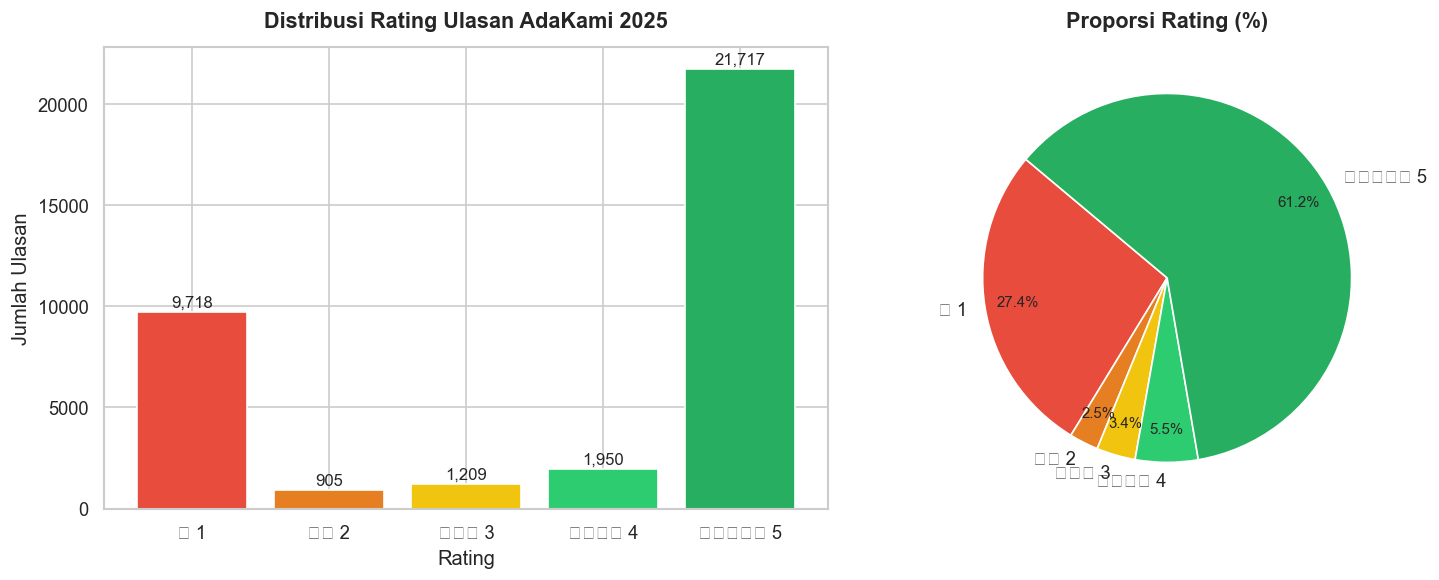


📊 TABEL DISTRIBUSI RATING:
 Rating  Jumlah  Persentase (%)
      1    9718           27.38
      2     905            2.55
      3    1209            3.41
      4    1950            5.49
      5   21717           61.18

Total: 35,499 ulasan


In [4]:
rating_counts = df['rating'].value_counts().sort_index()
rating_labels = {1: '⭐ 1', 2: '⭐⭐ 2', 3: '⭐⭐⭐ 3', 4: '⭐⭐⭐⭐ 4', 5: '⭐⭐⭐⭐⭐ 5'}
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ax1 = axes[0]
bars = ax1.bar([rating_labels[r] for r in rating_counts.index], rating_counts.values, color=colors)
ax1.set_title('Distribusi Rating Ulasan AdaKami 2025', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Rating')
ax1.set_ylabel('Jumlah Ulasan')
for bar, val in zip(bars, rating_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    rating_counts.values,
    labels=[rating_labels[r] for r in rating_counts.index],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Proporsi Rating (%)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('gambar_4_1_distribusi_rating.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 TABEL DISTRIBUSI RATING:')
tabel_rating = pd.DataFrame({
    'Rating': rating_counts.index,
    'Jumlah': rating_counts.values,
    'Persentase (%)': (rating_counts.values / len(df) * 100).round(2)
})
print(tabel_rating.to_string(index=False))
print(f'\nTotal: {len(df):,} ulasan')

### 🏷️ Cell 5 — Distribusi Sentimen (Negatif / Netral / Positif)

Pemetaan rating → label sentimen sesuai §3.4.1 BAB 3.

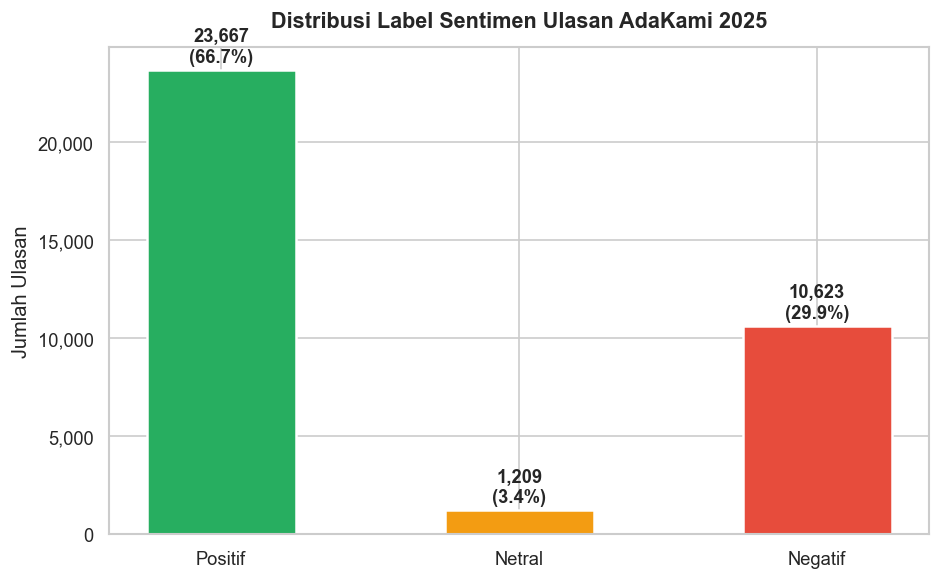


📊 TABEL DISTRIBUSI SENTIMEN:
   Positif: 23,667 ulasan (66.7%)
    Netral:  1,209 ulasan (3.4%)
   Negatif: 10,623 ulasan (29.9%)

⚖️  Rasio Positif:Negatif = 2.2:1
⚠️  Data TIDAK SEIMBANG → SMOTE diperlukan pada tahap pemodelan


In [5]:
def label_sentimen(rating):
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'

df['sentimen'] = df['rating'].apply(label_sentimen)

sentimen_counts = df['sentimen'].value_counts()
sentimen_order = ['Positif', 'Netral', 'Negatif']
sentimen_colors = {'Positif': '#27ae60', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    sentimen_order,
    [sentimen_counts[s] for s in sentimen_order],
    color=[sentimen_colors[s] for s in sentimen_order],
    width=0.5, edgecolor='white', linewidth=1.5
)
ax.set_title('Distribusi Label Sentimen Ulasan AdaKami 2025', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Jumlah Ulasan')
for bar in bars:
    h = bar.get_height()
    pct = h / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, h + 200,
            f'{h:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('gambar_4_2_distribusi_sentimen.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 TABEL DISTRIBUSI SENTIMEN:')
for s in sentimen_order:
    n = sentimen_counts[s]
    print(f'  {s:>8}: {n:>6,} ulasan ({n/len(df)*100:.1f}%)')

print()
# Evaluasi imbalance
pos = sentimen_counts.get('Positif', 0)
neg = sentimen_counts.get('Negatif', 0)
rasio = pos / neg
print(f'⚖️  Rasio Positif:Negatif = {rasio:.1f}:1')
# Cek rasio mayoritas (Positif) vs minoritas (Netral)
    rasio_smote = pos / net
    if rasio_smote > 3:
    print(f'⚠️  Rasio Positif:Netral = {rasio_smote:.1f}:1 (threshold 3:1) → SMOTE diperlukan')
else:
    print('✅ Data relatif seimbang')

### 📅 Cell 6 — Distribusi Ulasan Per Bulan

Melihat tren temporal — apakah ada bulan tertentu yang lonjakan ulasannya signifikan? Ini menjawab **RQ2** tentang tren temporal. Grafik ini masuk **BAB 4 Gambar 4.3**.

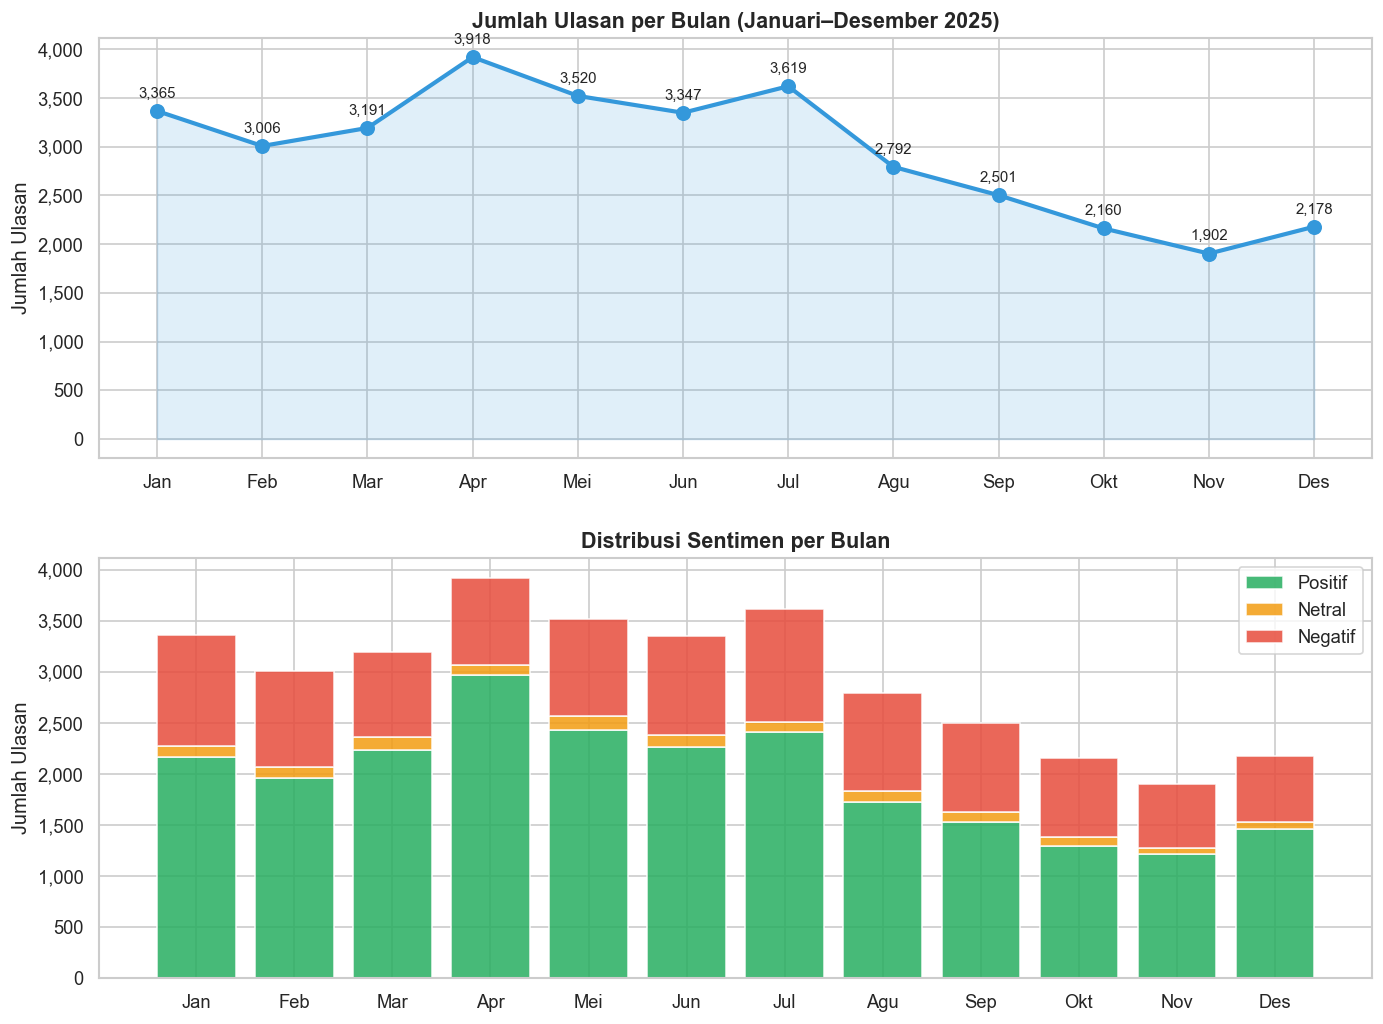


📊 TABEL DISTRIBUSI PER BULAN:
Bulan  Total  Positif  Netral  Negatif
  Jan   3365     2163     113     1089
  Feb   3006     1963     101      942
  Mar   3191     2239     125      827
  Apr   3918     2970      95      853
  Mei   3520     2431     132      957
  Jun   3347     2261     119      967
  Jul   3619     2413      97     1109
  Agu   2792     1725     109      958
  Sep   2501     1525     107      869
  Okt   2160     1297      88      775
  Nov   1902     1217      59      626
  Des   2178     1463      64      651


In [6]:
nama_bulan = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun',
    7:'Jul', 8:'Agu', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Des'
}

# Hitung per bulan per sentimen
bulanan = df.groupby(['bulan', 'sentimen']).size().unstack(fill_value=0)
total_bulanan = df.groupby('bulan').size()

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Plot 1: Total ulasan per bulan
ax1 = axes[0]
bulan_labels = [nama_bulan[b] for b in total_bulanan.index]
ax1.plot(bulan_labels, total_bulanan.values, marker='o', color='#3498db',
         linewidth=2.5, markersize=8, label='Total Ulasan')
ax1.fill_between(bulan_labels, total_bulanan.values, alpha=0.15, color='#3498db')
for i, (b, v) in enumerate(zip(bulan_labels, total_bulanan.values)):
    ax1.annotate(f'{v:,}', (b, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax1.set_title('Jumlah Ulasan per Bulan (Januari–Desember 2025)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Jumlah Ulasan')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Plot 2: Distribusi sentimen per bulan (stacked bar)
ax2 = axes[1]
colors_sent = {'Positif': '#27ae60', 'Netral': '#f39c12', 'Negatif': '#e74c3c'}
bottom = np.zeros(12)
for sentimen in ['Positif', 'Netral', 'Negatif']:
    if sentimen in bulanan.columns:
        vals = [bulanan.loc[b, sentimen] if b in bulanan.index else 0 for b in range(1, 13)]
        ax2.bar(bulan_labels, vals, bottom=bottom, label=sentimen,
               color=colors_sent[sentimen], alpha=0.85)
        bottom += np.array(vals)
ax2.set_title('Distribusi Sentimen per Bulan', fontsize=13, fontweight='bold')
ax2.set_ylabel('Jumlah Ulasan')
ax2.legend(loc='upper right')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout(pad=2)
plt.savefig('gambar_4_3_distribusi_bulanan.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 TABEL DISTRIBUSI PER BULAN:')
tabel_bln = pd.DataFrame({
    'Bulan': [nama_bulan[b] for b in total_bulanan.index],
    'Total': total_bulanan.values,
    'Positif': [bulanan.loc[b,'Positif'] if 'Positif' in bulanan.columns else 0 for b in range(1,13)],
    'Netral':  [bulanan.loc[b,'Netral']  if 'Netral'  in bulanan.columns else 0 for b in range(1,13)],
    'Negatif': [bulanan.loc[b,'Negatif'] if 'Negatif' in bulanan.columns else 0 for b in range(1,13)],
})
print(tabel_bln.to_string(index=False))

### 📏 Cell 7 — Analisis Panjang Teks Ulasan

Mengetahui distribusi panjang teks penting untuk:
1. Memahami kualitas data (teks terlalu pendek = noise)
2. Menentukan apakah perlu filter panjang minimum di preprocessing

📊 STATISTIK PANJANG TEKS ULASAN
Rata-rata karakter  :     57.5
Median karakter     :     27.0
Min karakter        :        1
Max karakter        :      500
Rata-rata kata      :      9.2
Median kata         :      4.0


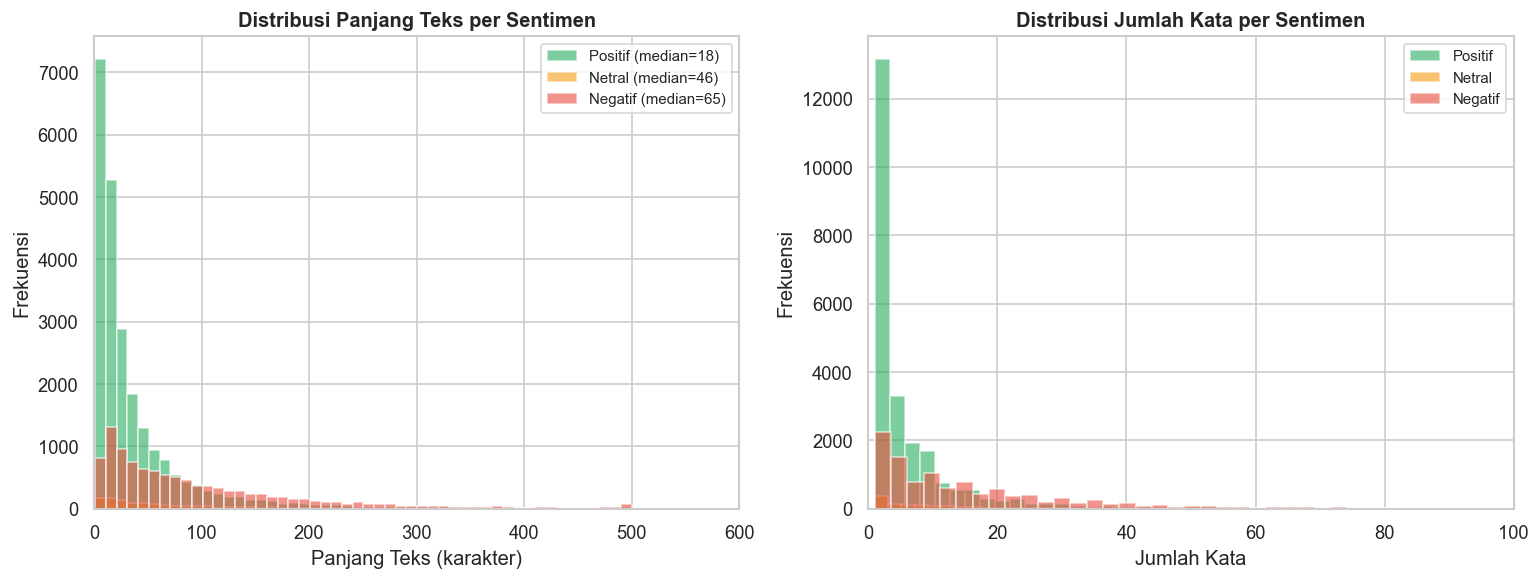


📊 RATA-RATA PANJANG TEKS PER SENTIMEN:
   Positif: rata-rata 39 karakter, 6.0 kata
    Netral: rata-rata 77 karakter, 12.7 kata
   Negatif: rata-rata 97 karakter, 15.7 kata

⚠️  Ulasan ≤ 3 kata: 15,773 (44.4%) — akan ditangani di preprocessing


In [7]:
df['panjang_teks'] = df['teks_ulasan'].fillna('').str.len()
df['jumlah_kata'] = df['teks_ulasan'].fillna('').str.split().str.len()

print('📊 STATISTIK PANJANG TEKS ULASAN')
print('=' * 45)
stats = df['panjang_teks'].describe().round(1)
stats_kata = df['jumlah_kata'].describe().round(1)
print(f'Rata-rata karakter  : {stats["mean"]:>8.1f}')
print(f'Median karakter     : {stats["50%"]:>8.1f}')
print(f'Min karakter        : {stats["min"]:>8.0f}')
print(f'Max karakter        : {stats["max"]:>8.0f}')
print(f'Rata-rata kata      : {stats_kata["mean"]:>8.1f}')
print(f'Median kata         : {stats_kata["50%"]:>8.1f}')

# Distribusi panjang per sentimen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
for sent, color in [('Positif','#27ae60'), ('Netral','#f39c12'), ('Negatif','#e74c3c')]:
    subset = df[df['sentimen'] == sent]['panjang_teks']
    subset.hist(ax=ax1, bins=50, alpha=0.6, color=color, label=f'{sent} (median={subset.median():.0f})')
ax1.set_xlim(0, 600)
ax1.set_title('Distribusi Panjang Teks per Sentimen', fontsize=12, fontweight='bold')
ax1.set_xlabel('Panjang Teks (karakter)')
ax1.set_ylabel('Frekuensi')
ax1.legend(fontsize=9)

ax2 = axes[1]
for sent, color in [('Positif','#27ae60'), ('Netral','#f39c12'), ('Negatif','#e74c3c')]:
    subset = df[df['sentimen'] == sent]['jumlah_kata']
    subset.hist(ax=ax2, bins=40, alpha=0.6, color=color, label=f'{sent}')
ax2.set_xlim(0, 100)
ax2.set_title('Distribusi Jumlah Kata per Sentimen', fontsize=12, fontweight='bold')
ax2.set_xlabel('Jumlah Kata')
ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('gambar_4_4_distribusi_panjang_teks.png', bbox_inches='tight', dpi=150)
plt.show()

print()
print('📊 RATA-RATA PANJANG TEKS PER SENTIMEN:')
for sent in ['Positif', 'Netral', 'Negatif']:
    subset = df[df['sentimen'] == sent]
    print(f'  {sent:>8}: rata-rata {subset["panjang_teks"].mean():.0f} karakter, '
          f'{subset["jumlah_kata"].mean():.1f} kata')

# Ulasan sangat pendek (≤ 3 kata) — kandidat noise
sangat_pendek = (df['jumlah_kata'] <= 3).sum()
print(f'\n⚠️  Ulasan ≤ 3 kata: {sangat_pendek:,} ({sangat_pendek/len(df)*100:.1f}%) — akan ditangani di preprocessing')

### 🔥 Cell 8 — Heatmap Sentimen per Bulan

Visualisasi ini memperlihatkan *proporsi* sentimen negatif setiap bulan — apakah ada bulan tertentu yang proporsi negatifnya melonjak? Masuk **BAB 4 Gambar 4.5**.

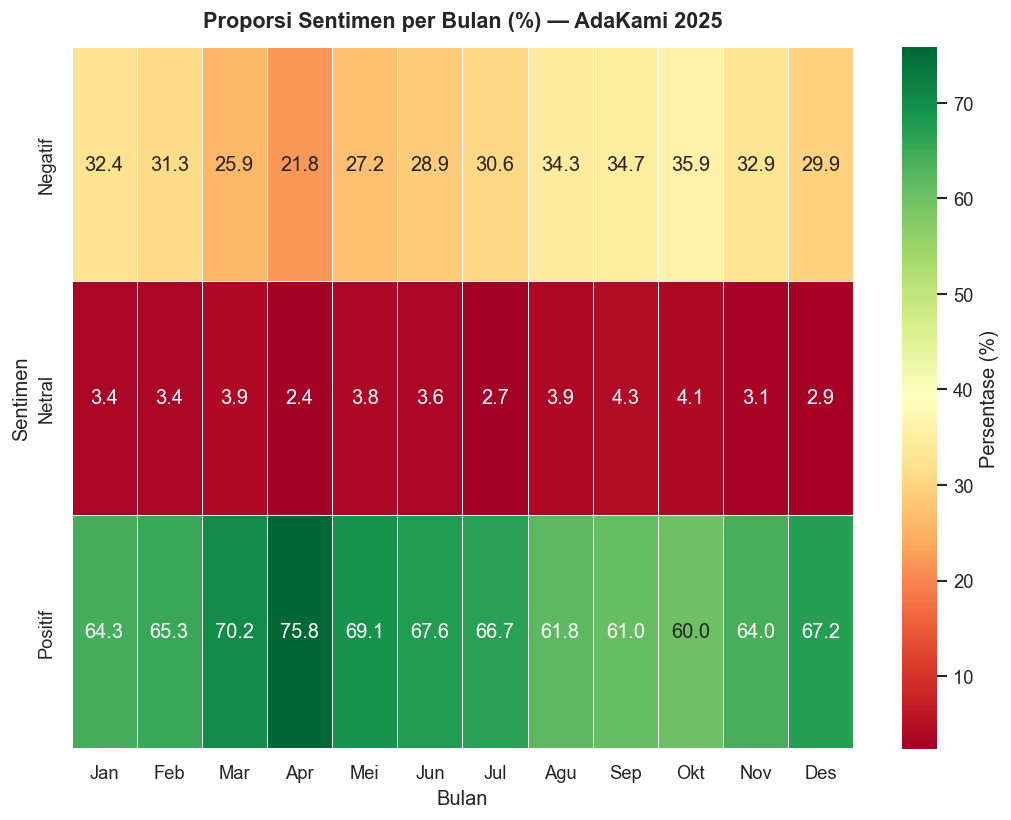


📊 PROPORSI SENTIMEN PER BULAN (%)
sentimen  Negatif  Netral  Positif
Jan          32.4     3.4     64.3
Feb          31.3     3.4     65.3
Mar          25.9     3.9     70.2
Apr          21.8     2.4     75.8
Mei          27.2     3.8     69.1
Jun          28.9     3.6     67.6
Jul          30.6     2.7     66.7
Agu          34.3     3.9     61.8
Sep          34.7     4.3     61.0
Okt          35.9     4.1     60.0
Nov          32.9     3.1     64.0
Des          29.9     2.9     67.2

🔴 Bulan dengan proporsi negatif tertinggi: Okt (35.9%)


In [8]:
# Proporsi sentimen per bulan (dalam %)
pivot = df.groupby(['bulan', 'sentimen']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Rename index ke nama bulan
pivot_pct.index = [nama_bulan[b] for b in pivot_pct.index]

# Urutkan kolom
kolom_urut = [c for c in ['Negatif', 'Netral', 'Positif'] if c in pivot_pct.columns]
pivot_pct = pivot_pct[kolom_urut]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    pivot_pct.T,
    annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Persentase (%)'}
)
ax.set_title('Proporsi Sentimen per Bulan (%) — AdaKami 2025',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Bulan')
ax.set_ylabel('Sentimen')
plt.tight_layout()
plt.savefig('gambar_4_5_heatmap_sentimen_bulanan.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 PROPORSI SENTIMEN PER BULAN (%)')
print(pivot_pct.round(1).to_string())

# Identifikasi bulan dengan negatif tertinggi
if 'Negatif' in pivot_pct.columns:
    bulan_negatif_max = pivot_pct['Negatif'].idxmax()
    nilai_max = pivot_pct['Negatif'].max()
    print(f'\n🔴 Bulan dengan proporsi negatif tertinggi: {bulan_negatif_max} ({nilai_max:.1f}%)')

### 🔤 Cell 9 — Analisis Frekuensi Kata (Top 20)

Kata-kata yang paling sering muncul di ulasan negatif vs positif memberikan gambaran isu utama yang dihadapi pengguna AdaKami. Ini menjawab **RQ4** tentang topik dominan. Masuk **BAB 4 §4.2**.

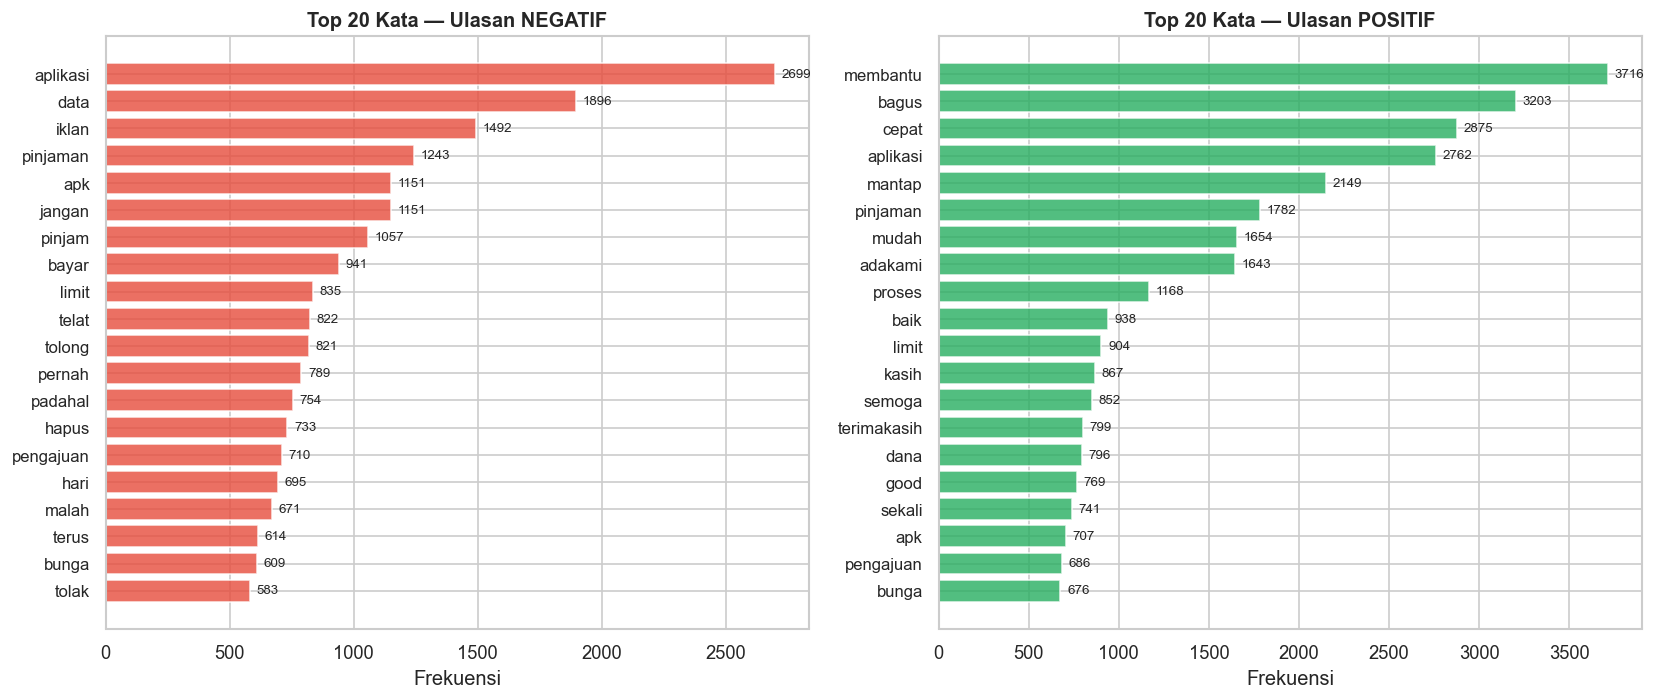


🔴 TOP 10 KATA ULASAN NEGATIF:
   1. aplikasi              2699x
   2. data                  1896x
   3. iklan                 1492x
   4. pinjaman              1243x
   5. apk                   1151x
   6. jangan                1151x
   7. pinjam                1057x
   8. bayar                  941x
   9. limit                  835x
  10. telat                  822x

🟢 TOP 10 KATA ULASAN POSITIF:
   1. membantu              3716x
   2. bagus                 3203x
   3. cepat                 2875x
   4. aplikasi              2762x
   5. mantap                2149x
   6. pinjaman              1782x
   7. mudah                 1654x
   8. adakami               1643x
   9. proses                1168x
  10. baik                   938x


In [9]:
# Stopwords sederhana (belum full preprocessing — itu di Step 4)
# Ini hanya untuk EDA awal
stopwords_awal = set([
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'ini',
    'itu', 'tidak', 'ada', 'saya', 'aku', 'nya', 'juga', 'sudah',
    'saja', 'bisa', 'lebih', 'kalau', 'tapi', 'karena', 'atau',
    'pada', 'ya', 'jadi', 'lagi', 'masih', 'mau', 'aja', 'dah',
    'udah', 'sama', 'sangat', 'banget', 'kali', 'maka', 'buat',
    'se', 'nya', 'lah', 'kan', 'pun', 'pake', 'pakai', 'dong',
    'nih', 'gimana', 'kayak', 'gak', 'ga', 'gak', 'nggak', 'ngga',
    'yg', 'tp', 'krn', 'dgn', 'dr', 'sy', 'sdh', 'blm', 'lg'
])

def hitung_kata(teks_series, top_n=20):
    semua_kata = []
    for teks in teks_series.fillna(''):
        kata_list = str(teks).lower().split()
        kata_list = [k for k in kata_list if k not in stopwords_awal and len(k) > 2]
        semua_kata.extend(kata_list)
    return Counter(semua_kata).most_common(top_n)

top_negatif = hitung_kata(df[df['sentimen'] == 'Negatif']['teks_ulasan'])
top_positif = hitung_kata(df[df['sentimen'] == 'Positif']['teks_ulasan'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top_words, title, color in [
    (axes[0], top_negatif, 'Top 20 Kata — Ulasan NEGATIF', '#e74c3c'),
    (axes[1], top_positif, 'Top 20 Kata — Ulasan POSITIF', '#27ae60')
]:
    kata, frek = zip(*top_words)
    y_pos = range(len(kata))
    ax.barh(y_pos, frek, color=color, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(kata, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    for i, (k, f) in enumerate(zip(kata, frek)):
        ax.text(f + max(frek)*0.01, i, str(f), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('gambar_4_6_top_kata.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n🔴 TOP 10 KATA ULASAN NEGATIF:')
for rank, (kata, frek) in enumerate(top_negatif[:10], 1):
    print(f'  {rank:>2}. {kata:<20} {frek:>5}x')

print('\n🟢 TOP 10 KATA ULASAN POSITIF:')
for rank, (kata, frek) in enumerate(top_positif[:10], 1):
    print(f'  {rank:>2}. {kata:<20} {frek:>5}x')

### 📱 Cell 10 — Distribusi Versi Aplikasi

Melihat versi app mana yang paling banyak menerima ulasan negatif — berguna untuk rekomendasi bisnis di BAB 5.

In [10]:
top_versi = df['versi_app'].value_counts().head(10)

print('📱 TOP 10 VERSI APLIKASI:')
tabel_versi = pd.DataFrame({
    'Versi': top_versi.index,
    'Jumlah Ulasan': top_versi.values,
    'Persen (%)': (top_versi.values / len(df) * 100).round(2)
})
print(tabel_versi.to_string(index=False))

# Rata-rata rating per versi
print()
print('⭐ RATA-RATA RATING PER VERSI (top 10):')
avg_rating_versi = df[df['versi_app'].isin(top_versi.index)].groupby('versi_app')['rating'].mean().round(2)
print(avg_rating_versi.sort_values().to_string())

📱 TOP 10 VERSI APLIKASI:
 Versi  Jumlah Ulasan  Persen (%)
 6.9.0           4540       12.79
 6.7.0           2803        7.90
 7.1.0           1952        5.50
 7.4.0           1589        4.48
 7.6.1           1553        4.37
7.10.0           1375        3.87
 7.1.1           1278        3.60
 7.9.0           1094        3.08
 6.8.0           1006        2.83
 7.5.1            946        2.66

⭐ RATA-RATA RATING PER VERSI (top 10):
versi_app
7.6.1     3.90
7.9.0     3.94
7.5.1     3.95
6.7.0     3.96
7.4.0     4.01
7.1.1     4.07
7.1.0     4.13
7.10.0    4.13
6.8.0     4.16
6.9.0     4.27


### ✅ Cell 11 — Ringkasan EDA & Output untuk BAB 4

Semua angka penting yang akan langsung dipakai untuk menulis BAB 4 §4.1.

In [11]:
print('=' * 60)
print('📋 RINGKASAN EDA — UNTUK PENULISAN BAB 4')
print('=' * 60)

total = len(df)
sentimen_counts = df['sentimen'].value_counts()
pos = sentimen_counts.get('Positif', 0)
net = sentimen_counts.get('Netral', 0)
neg = sentimen_counts.get('Negatif', 0)

print(f"""
§4.1 DESKRIPSI DATASET
----------------------
• Total ulasan terkumpul     : {total:,} ulasan
• Periode data               : Januari – Desember 2025
• Sumber                     : Google Play Store (google-play-scraper)
• Kolom data                 : {len(df.columns)} fitur
• Duplikat                   : 0 (sudah dibersihkan saat scraping)
• Missing value teks_ulasan  : {df['teks_ulasan'].isna().sum()} ulasan

§4.1.1 DISTRIBUSI RATING
------------------------
• Rating 1  : {(df['rating']==1).sum():>6,} ulasan ({(df['rating']==1).sum()/total*100:.1f}%)
• Rating 2  : {(df['rating']==2).sum():>6,} ulasan ({(df['rating']==2).sum()/total*100:.1f}%)
• Rating 3  : {(df['rating']==3).sum():>6,} ulasan ({(df['rating']==3).sum()/total*100:.1f}%)
• Rating 4  : {(df['rating']==4).sum():>6,} ulasan ({(df['rating']==4).sum()/total*100:.1f}%)
• Rating 5  : {(df['rating']==5).sum():>6,} ulasan ({(df['rating']==5).sum()/total*100:.1f}%)

§4.1.2 DISTRIBUSI SENTIMEN
---------------------------
• Positif (rating 4–5) : {pos:>6,} ulasan ({pos/total*100:.1f}%)
• Netral  (rating 3)   : {net:>6,} ulasan ({net/total*100:.1f}%)
• Negatif (rating 1–2) : {neg:>6,} ulasan ({neg/total*100:.1f}%)
• Rasio Positif:Negatif = {pos/neg:.1f}:1 → DATA TIDAK SEIMBANG → perlu SMOTE

§4.1.3 KARAKTERISTIK TEKS
--------------------------
• Rata-rata panjang teks   : {df['panjang_teks'].mean():.0f} karakter
• Median panjang teks      : {df['panjang_teks'].median():.0f} karakter
• Rata-rata jumlah kata    : {df['jumlah_kata'].mean():.1f} kata
• Ulasan sangat pendek (≤3 kata) : {(df['jumlah_kata'] <= 3).sum():,} ulasan

§4.1.4 TREN TEMPORAL
---------------------
• Bulan terbanyak ulasan  : {nama_bulan[total_bulanan.idxmax()]} ({total_bulanan.max():,} ulasan)
• Bulan tersedikit ulasan : {nama_bulan[total_bulanan.idxmin()]} ({total_bulanan.min():,} ulasan)
""")

print('=' * 60)
print('📁 FILE GRAFIK YANG TERSIMPAN:')
print('  gambar_4_1_distribusi_rating.png')
print('  gambar_4_2_distribusi_sentimen.png')
print('  gambar_4_3_distribusi_bulanan.png')
print('  gambar_4_4_distribusi_panjang_teks.png')
print('  gambar_4_5_heatmap_sentimen_bulanan.png')
print('  gambar_4_6_top_kata.png')
print()
print('✅ EDA selesai! Lanjut ke Step 3: Labeling & Validasi Cohen\'s Kappa')

📋 RINGKASAN EDA — UNTUK PENULISAN BAB 4

§4.1 DESKRIPSI DATASET
----------------------
• Total ulasan terkumpul     : 35,499 ulasan
• Periode data               : Januari – Desember 2025
• Sumber                     : Google Play Store (google-play-scraper)
• Kolom data                 : 12 fitur
• Duplikat                   : 0 (sudah dibersihkan saat scraping)
• Missing value teks_ulasan  : 0 ulasan

§4.1.1 DISTRIBUSI RATING
------------------------
• Rating 1  :  9,718 ulasan (27.4%)
• Rating 2  :    905 ulasan (2.5%)
• Rating 3  :  1,209 ulasan (3.4%)
• Rating 4  :  1,950 ulasan (5.5%)
• Rating 5  : 21,717 ulasan (61.2%)

§4.1.2 DISTRIBUSI SENTIMEN
---------------------------
• Positif (rating 4–5) : 23,667 ulasan (66.7%)
• Netral  (rating 3)   :  1,209 ulasan (3.4%)
• Negatif (rating 1–2) : 10,623 ulasan (29.9%)
• Rasio Positif:Negatif = 2.2:1 → DATA TIDAK SEIMBANG → perlu SMOTE

§4.1.3 KARAKTERISTIK TEKS
--------------------------
• Rata-rata panjang teks   : 58 karakter
• Median

---
## ✅ STEP 2 SELESAI — Checklist Sebelum Lanjut

Sebelum pindah ke Step 3 (Labeling), pastikan:

- [ ] Cell 11 menampilkan ringkasan tanpa error
- [ ] Semua 6 file gambar tersimpan di folder IMPLEMENTASI
- [ ] Catat angka-angka penting dari Cell 11 → akan langsung dipakai di BAB 4 §4.1
- [ ] Rasio imbalance sudah diketahui (Positif:Negatif) → konfirmasi perlu SMOTE

**Jika ada grafik yang error:** Screenshot output dan tunjukkan — kita troubleshoot.

**Jika sudah ✅ semua:** Lanjut ke `step3_labeling.ipynb` 🎉